# Connectivity Network Visualisation

Visualise strong structural and functional connections and categorise where the two networks agree or differ.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


In [1]:
from pathlib import Path
figure_dir = Path("figures/connectivity_network_visualisation")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd

base_path = "data/connectomes/"

In [2]:
def load_data(file_path):
    try:
        with open(file_path, 'r') as f:
            for line in f:
                if line.startswith("#"):
                    labels = line.split(":")[1].strip().split(",")
        
        data = pd.read_csv(file_path, header=None, comment="#")
        data.columns = labels
        data.index = labels
        print(data.shape)
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_pair(patient_id):
    wfa_file = f"{base_path}{patient_id}_WFA_68.csv"
    rsfmri_file = f"{base_path}{patient_id}_rsfMRI_68.csv"
    wfa_data = load_data(wfa_file)
    rsfmri_data = load_data(rsfmri_file)
    if wfa_data is not None and rsfmri_data is not None:
        return wfa_data, rsfmri_data
    else:
        print(f"Error loading data for patient {patient_id}")
        return None, None
    
example_patient_id = "32"
wfa, rsfmri = load_pair(example_patient_id)
if wfa is not None and rsfmri is not None:
    # print("WFA Data:")
    # print(wfa.head())
    # print("\nrsfMRI Data:")
    # print(rsfmri.head())
    # find threshold for rsmfri strong positive and negative connections
    rsmfri_edges = rsfmri.values.flatten()
    rsmfri_edges = rsmfri_edges[rsmfri_edges != 1] 
    rsmfri_edges = rsmfri_edges[rsmfri_edges != 0]
    rsmfri_positive_edges = rsmfri_edges[rsmfri_edges > 0]
    rsmfri_negative_edges = rsmfri_edges[rsmfri_edges < 0]
    print(f"rsfMRI edge stats: min={rsmfri_edges.min()}, max={rsmfri_edges.max()}, mean={rsmfri_edges.mean()}, std={rsmfri_edges.std()}")
    print(f"rsfMRI positive edge stats: min={rsmfri_positive_edges.min()}, max={rsmfri_positive_edges.max()}, mean={rsmfri_positive_edges.mean()}, std={rsmfri_positive_edges.std()}")
    print(f"rsfMRI negative edge stats: min={rsmfri_negative_edges.min()}, max={rsmfri_negative_edges.max()}, mean={rsmfri_negative_edges.mean()}, std={rsmfri_negative_edges.std()}")

    positive_threshold = rsmfri_positive_edges.mean() + 2 * rsmfri_positive_edges.std()
    negative_threshold = rsmfri_negative_edges.mean() - 2 * rsmfri_negative_edges.std()
    print(f"Suggested positive threshold: {positive_threshold}")
    print(f"Suggested negative threshold: {negative_threshold}")



    
    
    

(68, 68)
(68, 68)
rsfMRI edge stats: min=-0.462204107578187, max=0.196275248364571, mean=-0.012333830284956786, std=0.07165377683809823
rsfMRI positive edge stats: min=7.06715717589494e-05, max=0.196275248364571, mean=0.04314813761364494, std=0.032673828020701096
rsfMRI negative edge stats: min=-0.462204107578187, max=-3.50403186374635e-05, mean=-0.06087484417484455, std=0.060355724322842454
Suggested positive threshold: 0.10849579365504713
Suggested negative threshold: -0.18158629282052946


In [3]:
import numpy as np

print(np.allclose(wfa, wfa.T))
print(np.allclose(rsfmri, rsfmri.T))

True
True


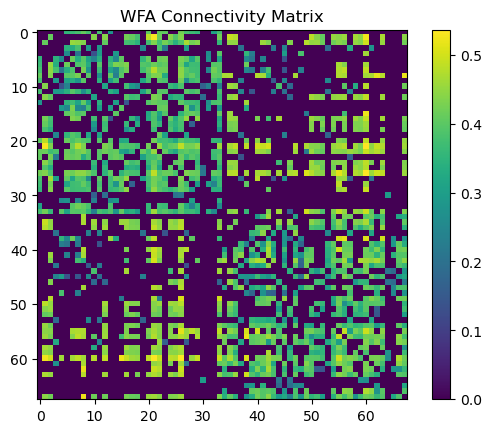

In [4]:
import matplotlib.pyplot as plt

plt.imshow(wfa, cmap='viridis')
plt.colorbar()
plt.title("WFA Connectivity Matrix")
plt.show()

Thresholds:
{'s_thr': np.float64(0.462927628214999), 'f_pos_thr': np.float64(0.08864966583535436), 'f_neg_thr': np.float64(0.1265566996372962)}


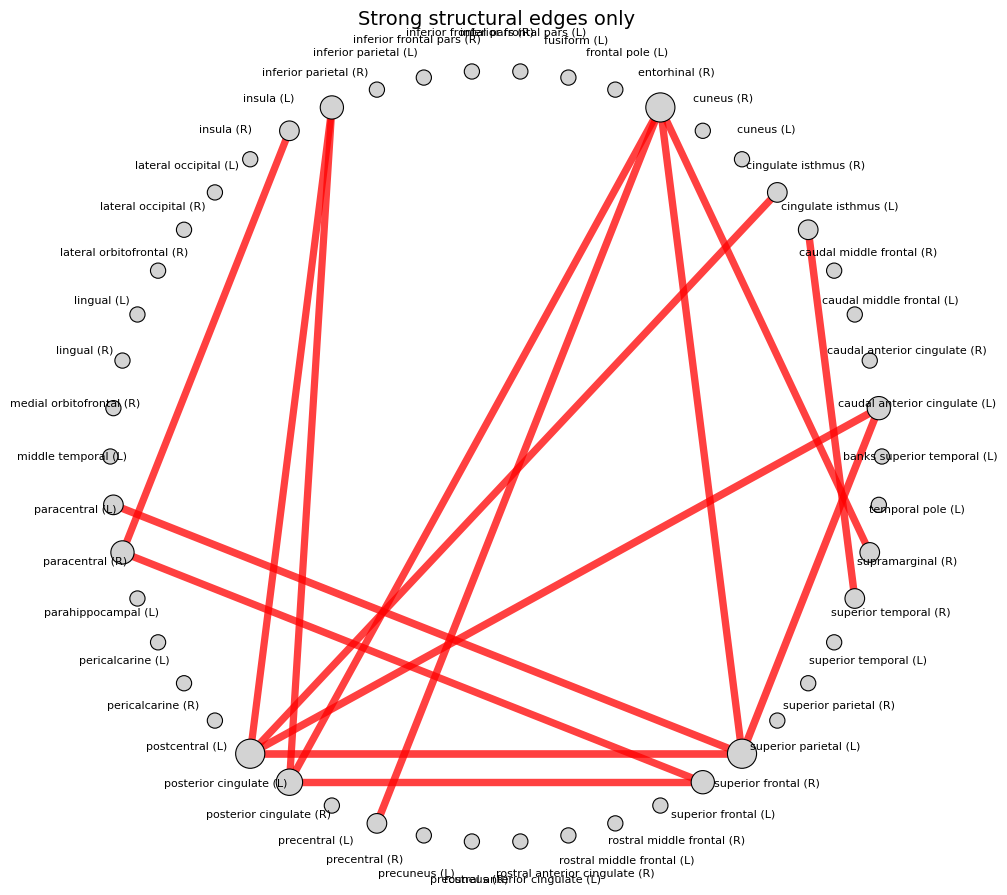

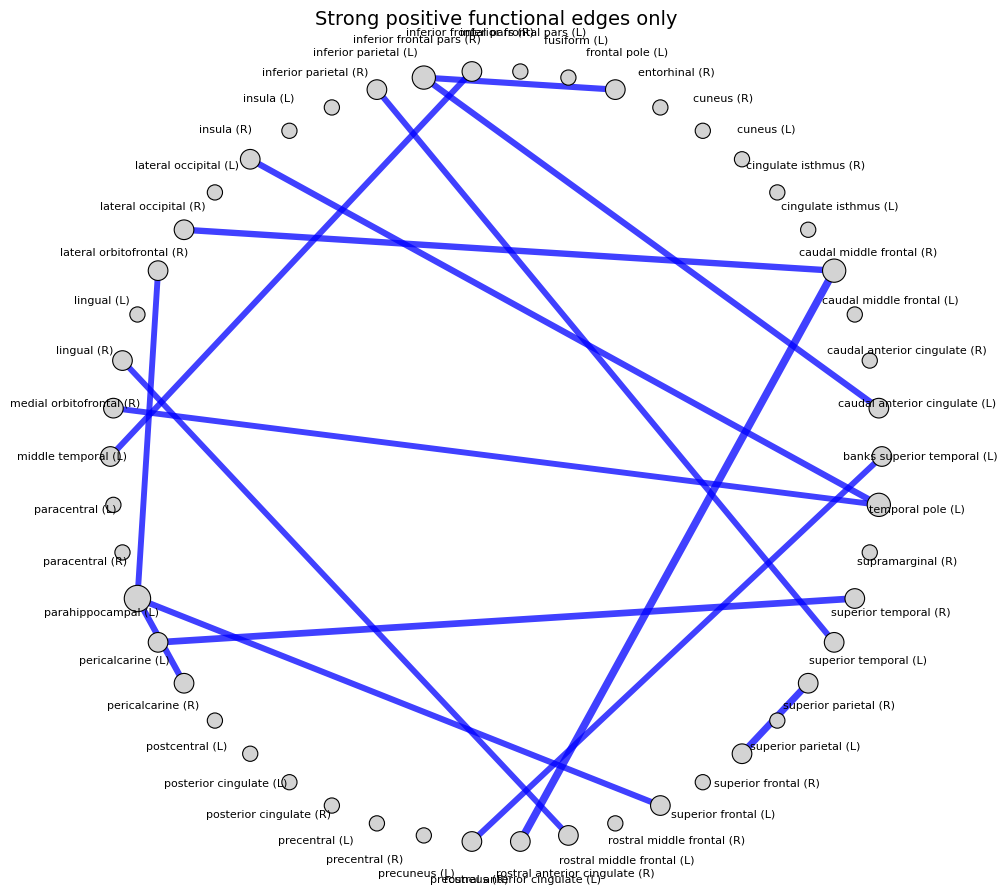

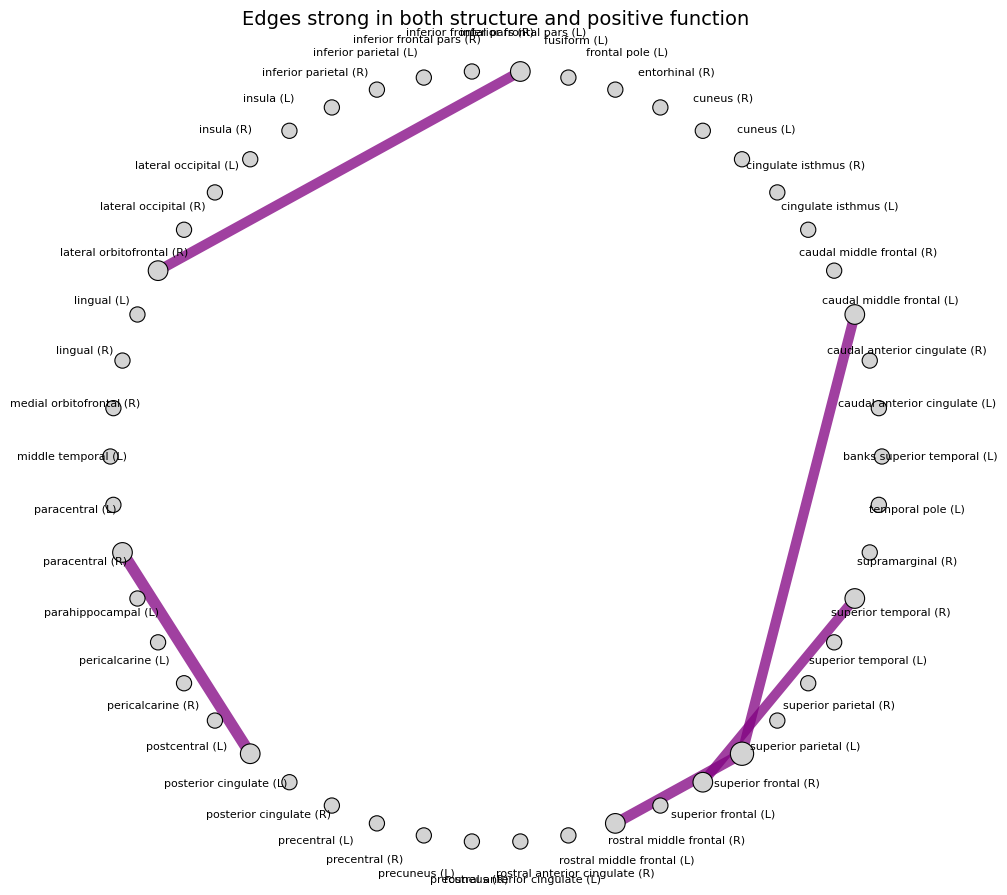

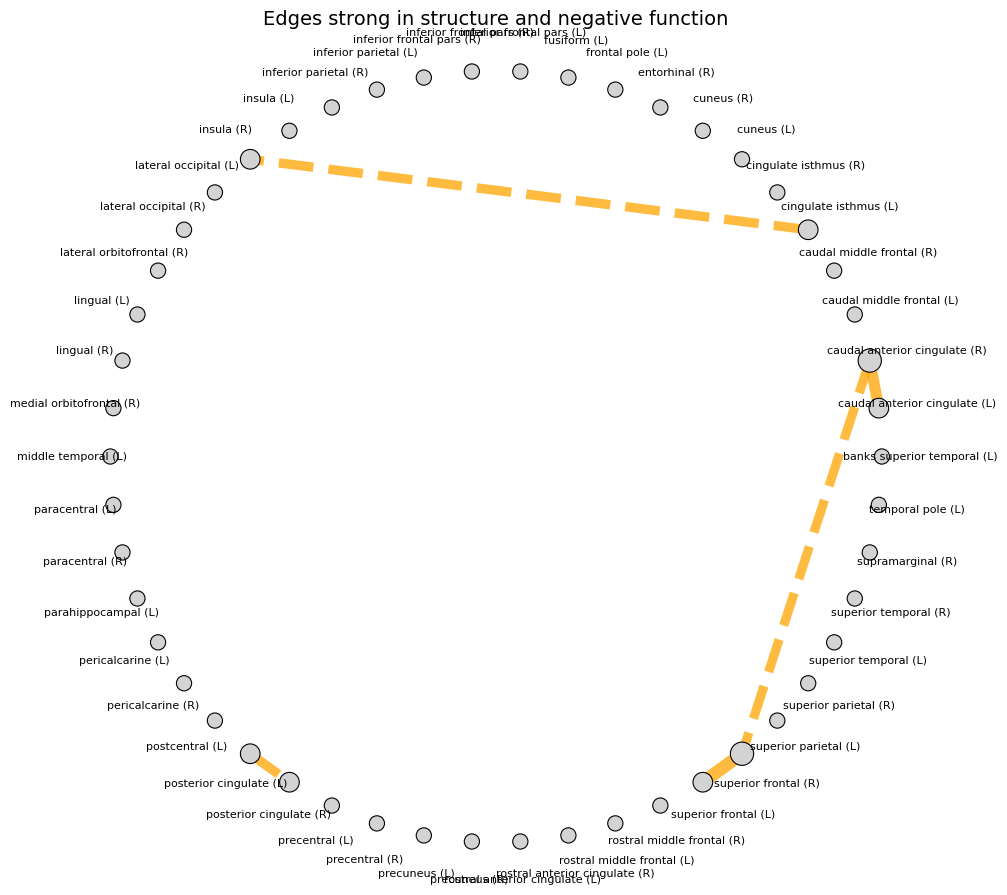

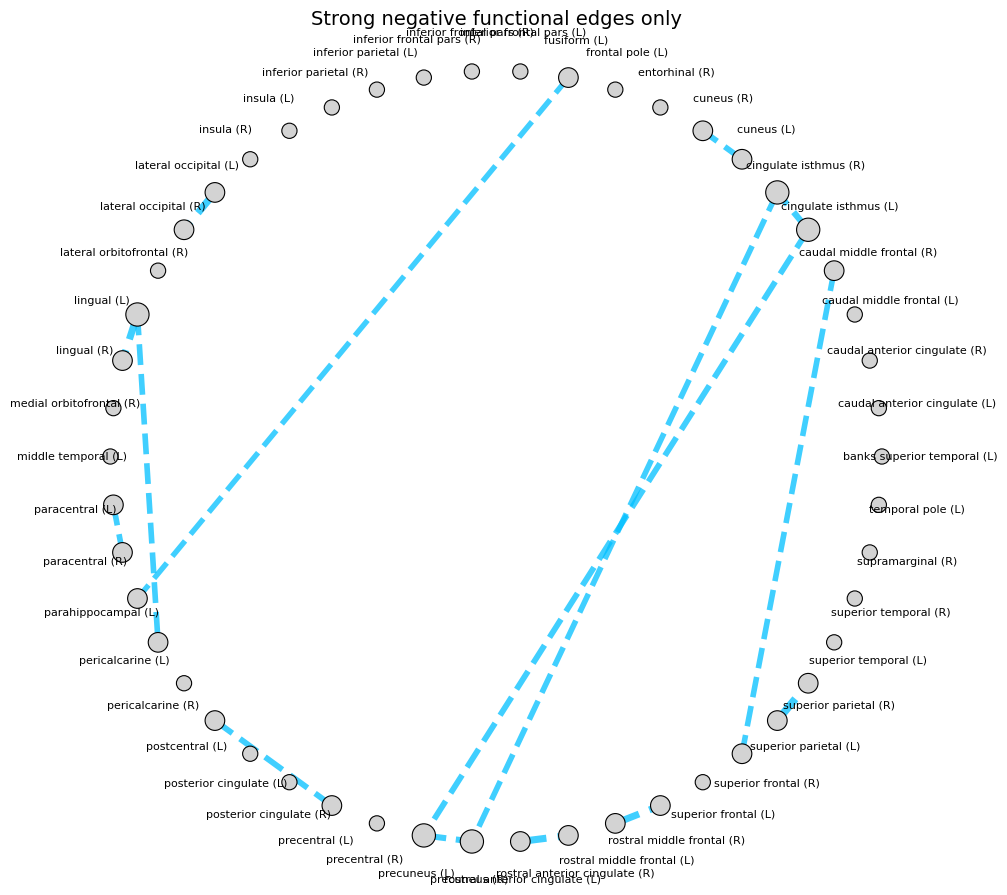

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


# ----------------------------
# 1. Load connectome matrices
# ----------------------------
def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break

    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]

    df = pd.read_csv(path, header=None, comment="#")

    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names

    return df


# -----------------------------------
# 2. Convert matrices to an edge list
# -----------------------------------
def build_edge_table(S, F):
    mask = np.triu(np.ones(S.shape, dtype=bool), 1)
    rows, cols = np.where(mask)

    edges = pd.DataFrame({
        "i_idx": rows,
        "j_idx": cols,
        "i": [S.index[r] for r in rows],
        "j": [S.columns[c] for c in cols],
        "s": S.values[mask],   # WFA structural weight
        "f": F.values[mask],   # rsfMRI functional correlation
    })

    return edges


# ---------------------------------------------------------
# 3. Categorize edges using separate structural/functional
#    thresholds
# ---------------------------------------------------------
def categorize_edges(edges, s_quantile=0.90, f_quantile=0.90):
    edges = edges.copy()

    s_nonzero = edges.loc[edges["s"] > 0, "s"]
    f_pos = edges.loc[edges["f"] > 0, "f"]
    f_neg_abs = edges.loc[edges["f"] < 0, "f"].abs()

    s_thr = s_nonzero.quantile(s_quantile) if len(s_nonzero) else 0
    f_pos_thr = f_pos.quantile(f_quantile) if len(f_pos) else 0
    f_neg_thr = f_neg_abs.quantile(f_quantile) if len(f_neg_abs) else 0

    def categorize(row):
        s_strong = row["s"] > s_thr
        f_pos_strong = row["f"] > f_pos_thr
        f_neg_strong = row["f"] < -f_neg_thr

        if s_strong and f_pos_strong:
            return "both_strong_positive_function"
        if s_strong and f_neg_strong:
            return "strong_structure_negative_function"
        if s_strong:
            return "structural_only"
        if f_pos_strong:
            return "functional_only_positive"
        if f_neg_strong:
            return "functional_only_negative"
        return "other"

    edges["category"] = edges.apply(categorize, axis=1)

    # Normalize values for ranking/linewidths
    def safe_norm(x):
        x = pd.Series(x)
        if len(x) == 0 or x.max() == x.min():
            return pd.Series(np.zeros(len(x)), index=x.index)
        return (x - x.min()) / (x.max() - x.min())

    edges["s_norm"] = safe_norm(edges["s"])
    edges["f_pos_norm"] = safe_norm(edges["f"].clip(lower=0))
    edges["f_neg_norm"] = safe_norm((-edges["f"]).clip(lower=0))

    def score(row):
        cat = row["category"]
        if cat == "both_strong_positive_function":
            return row["s_norm"] + row["f_pos_norm"]
        if cat == "strong_structure_negative_function":
            return row["s_norm"] + row["f_neg_norm"]
        if cat == "structural_only":
            return row["s_norm"]
        if cat == "functional_only_positive":
            return row["f_pos_norm"]
        if cat == "functional_only_negative":
            return row["f_neg_norm"]
        return 0

    edges["score"] = edges.apply(score, axis=1)

    thresholds = {
        "s_thr": s_thr,
        "f_pos_thr": f_pos_thr,
        "f_neg_thr": f_neg_thr,
    }

    return edges, thresholds


# --------------------------------------------------------
# 4. Select strongest edges, either overall or by category
# --------------------------------------------------------
def select_top_edges(edges, category=None, top_n=15):
    subset = edges.copy()
    if category is not None:
        subset = subset[subset["category"] == category]

    subset = subset.sort_values("score", ascending=False).head(top_n).copy()
    return subset


def select_top_edges_per_category(edges, top_n_dict):
    parts = []
    for cat, n in top_n_dict.items():
        part = select_top_edges(edges, category=cat, top_n=n)
        parts.append(part)
    if parts:
        return pd.concat(parts, ignore_index=True)
    return pd.DataFrame(columns=edges.columns)


# -------------------------------------
# 5. Build a node layout for plotting
# -------------------------------------
def build_circular_layout(nodes):
    nodes = list(nodes)
    angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
    return {node: (math.cos(a), math.sin(a)) for node, a in zip(nodes, angles)}


def short_label(name):
    hemi = ""
    if name.endswith("_left"):
        hemi = "L"
    elif name.endswith("_right"):
        hemi = "R"

    stem = name.replace("_left", "").replace("_right", "")
    parts = stem.split("_")

    stopwords = {"gyrus", "cortex"}
    parts = [p for p in parts if p not in stopwords]

    if len(parts) > 3:
        parts = parts[:3]

    text = " ".join(parts)
    if hemi:
        text += f" ({hemi})"
    return text


# --------------------------------------------------
# 6. Plot a network, optionally for one category only
# --------------------------------------------------
def plot_edge_network(
    edges_to_plot,
    node_order=None,
    pos=None,
    title="Connectome edge plot",
    show_labels=True,
    figsize=(11, 11),
    save_path=None
):
    if len(edges_to_plot) == 0:
        print("No edges to plot.")
        return

    if pos is None:
        if node_order is None:
            nodes = sorted(set(edges_to_plot["i"]).union(set(edges_to_plot["j"])))
        else:
            nodes = list(node_order)
        pos = build_circular_layout(nodes)
    else:
        nodes = list(pos.keys())

    degree = {node: 0 for node in nodes}
    for _, row in edges_to_plot.iterrows():
        degree[row["i"]] += 1
        degree[row["j"]] += 1

    color_map = {
        "both_strong_positive_function": "purple",
        "structural_only": "red",
        "functional_only_positive": "blue",
        "strong_structure_negative_function": "orange",
        "functional_only_negative": "deepskyblue",
    }

    linestyle_map = {
        "both_strong_positive_function": "-",
        "structural_only": "-",
        "functional_only_positive": "-",
        "strong_structure_negative_function": "--",
        "functional_only_negative": "--",
    }

    fig, ax = plt.subplots(figsize=figsize)

    for _, row in edges_to_plot.iterrows():
        x1, y1 = pos[row["i"]]
        x2, y2 = pos[row["j"]]
        lw = 1.5 + 4.0 * row["score"]

        ax.plot(
            [x1, x2], [y1, y2],
            color=color_map[row["category"]],
            linestyle=linestyle_map[row["category"]],
            linewidth=lw,
            alpha=0.75,
            zorder=1
        )

    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    sizes = [120 + 80 * degree[n] for n in nodes]

    ax.scatter(
        xs, ys,
        s=sizes,
        color="lightgray",
        edgecolor="black",
        linewidth=0.8,
        zorder=2
    )

    if show_labels:
        for n in nodes:
            x, y = pos[n]
            ax.text(
                1.10 * x, 1.10 * y,
                short_label(n),
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_title(title, fontsize=14)
    ax.set_aspect("equal")
    ax.axis("off")

    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")

    plt.show()


# -------------------------------------------------------
# 7. Helper to plot one category with fixed presentation
# -------------------------------------------------------
def plot_single_category(
    edges,
    category,
    top_n=15,
    node_order=None,
    save_path=None
):
    subset = select_top_edges(edges, category=category, top_n=top_n)

    pretty_titles = {
        "functional_only_positive": "Strong positive functional edges only",
        "functional_only_negative": "Strong negative functional edges only",
        "structural_only": "Strong structural edges only",
        "both_strong_positive_function": "Edges strong in both structure and positive function",
        "strong_structure_negative_function": "Edges strong in structure and negative function",
    }

    plot_edge_network(
        subset,
        node_order=node_order,
        title=f"{pretty_titles.get(category, category)}\nTop {len(subset)} edges",
        save_path=save_path
    )

    return subset

S = load_connectome(base_path + "32_WFA_68.csv")
F = load_connectome(base_path + "32_rsfMRI_68.csv")

edges = build_edge_table(S, F)
edges, thresholds = categorize_edges(edges, s_quantile=0.90, f_quantile=0.90)

print("Thresholds:")
print(thresholds)

# # -----------------------------------------
# # A. Plot one category at a time
# # -----------------------------------------
# func_pos_edges = plot_single_category(
#     edges,
#     category="functional_only_positive",
#     top_n=15,
#     save_path=str(figure_dir / 'functional_only_positive.png')
# )

# both_edges = plot_single_category(
#     edges,
#     category="both_strong_positive_function",
#     top_n=15,
#     save_path=str(figure_dir / 'both_strong_positive_function.png')
# )

# struct_only_edges = plot_single_category(
#     edges,
#     category="structural_only",
#     top_n=15,
#     save_path=str(figure_dir / 'structural_only.png')
# )

# -----------------------------------------
# B. Keep the same node set across slides
#    so comparison is easier in a deck
# -----------------------------------------

"""
 color_map = {
        "both_strong_positive_function": "purple",
        "structural_only": "red",
        "functional_only_positive": "blue",
        "strong_structure_negative_function": "orange",
        "functional_only_negative": "deepskyblue",
    }
"""

cats = [
    "functional_only_positive",
    "structural_only",
    "both_strong_positive_function",
    "strong_structure_negative_function",
    "functional_only_negative",
]

selected = {
    cat: select_top_edges(edges, category=cat, top_n=15)
    for cat in cats
}

presentation_nodes = sorted(set().union(*[
    set(df["i"]).union(df["j"]) for df in selected.values()
]))

shared_pos = build_circular_layout(presentation_nodes)
plot_edge_network(
    selected["structural_only"],
    pos=shared_pos,
    title="Strong structural edges only"
)
plot_edge_network(
    selected["functional_only_positive"],
    pos=shared_pos,
    title="Strong positive functional edges only"
)

plot_edge_network(
    selected["both_strong_positive_function"],
    pos=shared_pos,
    title="Edges strong in both structure and positive function"
)
plot_edge_network(
    selected["strong_structure_negative_function"],
    pos=shared_pos,
    title="Edges strong in structure and negative function"
)
plot_edge_network(
    selected["functional_only_negative"],
    pos=shared_pos,
    title="Strong negative functional edges only"
)




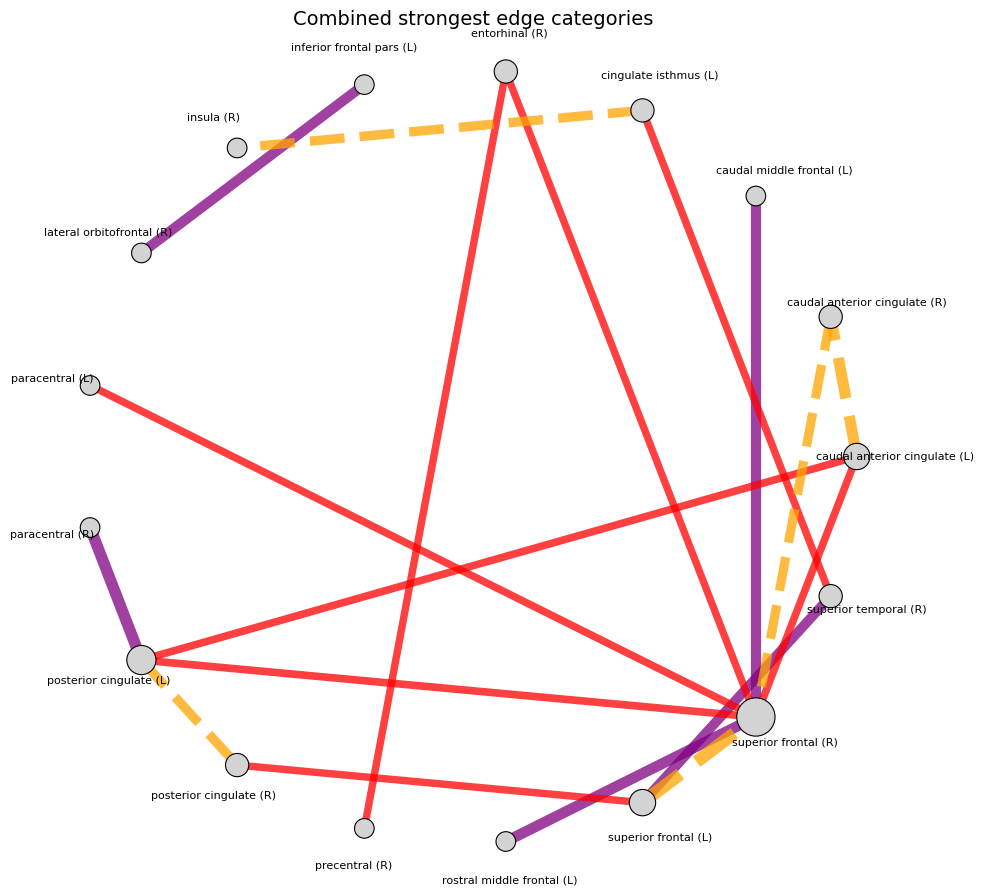

In [6]:

# -----------------------------------------
# C. Plot a combined network
# -----------------------------------------
combined = select_top_edges_per_category(edges, {
    # "functional_only_positive": 8,
    "both_strong_positive_function": 8,
    "structural_only": 8,
    # "functional_only_negative": 8,
    "strong_structure_negative_function": 8,
})

plot_edge_network(
    combined,
    title="Combined strongest edge categories",
    save_path=str(figure_dir / 'combined_connectome_categories.png')
)